# Corpus

In [1]:
!gdown 17W3bObZBL6XQVsVMSvkNildhsFSjsmhV

Downloading...
From: https://drive.google.com/uc?id=17W3bObZBL6XQVsVMSvkNildhsFSjsmhV
To: /home/Fer/Downloads/IMDB50K.csv
100%|██████████████████████████████████████| 66.2M/66.2M [00:03<00:00, 20.1MB/s]


## Función de limpieza

In [2]:
import re
import html

def clean_text(text):
    # Decodificar entidades HTML
    text = html.unescape(text)
    # Eliminar etiquetas HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # Normalizar espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# BERT fine-tuning

## Entrenamiento

### División train/test

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

imdb_df = pd.read_csv('IMDB50K.csv')
display(imdb_df)

y = LabelEncoder().fit_transform(imdb_df['sentiment'].values)

# Use .astype(object) or .to_numpy() to ensure compatibility
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    imdb_df['review'].to_numpy(), 
    y, 
    test_size=0.2, 
    random_state=642, 
    stratify=y
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_train_raw, y_train, test_size=0.25, random_state=473, stratify=y_train)
print(f"Training set size: {len(X_train_raw)}")
print(f"Validation set size: {len(X_val_raw)}")
print(f"Test set size: {len(X_test_raw)}")


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


Training set size: 30000
Validation set size: 10000
Test set size: 10000


In [ ]:
import numpy as np

random_idxs = np.random.choice(len(X_train_raw), size=4, replace=False)

for k in random_idxs:
    print(f"Review:\n{X_train_raw[k]}")

Review:
As part of our late 1950s vocabulary, we well knew the Ponderosa, Little Joe, Hoss, Ben Cartwright,etc. on that great show "Bonanza."<br /><br />It came Saturday night and everyone was glued to the television set. This was a real show depicting family values. There may have been a weekly crisis, but it was the strong family atmosphere that pulled everyone together.<br /><br />Lorne Greene was dominant as the patriarch of the family. His words depicted wisdom. We often were left to wonder that Ben Cartwright, a widower, must have been the best of husbands to that poor wife of his who had died. He reared wonderful sons.<br /><br />Naturally, we all wondered why Pernell Roberts left the show. The show was a gold mine and Roberts surrendered loads of money when he departed. His career never took off as he was associated as a Cartwright son. He should have tried to get back into the series. He certainly lost a bonanza by dropping out.
Review:
Woody Allen has lost his ability to writ

### Limpieza de variables


In [ ]:
train_docs = [clean_text(doc) for doc in X_train_raw]
test_docs = [clean_text(doc) for doc in X_test_raw]
val_docs = [clean_text(doc) for doc in X_val_raw]

In [ ]:
for k in random_idxs:
    print(f"Review:\n{train_docs[k]}")

Review:
As part of our late 1950s vocabulary, we well knew the Ponderosa, Little Joe, Hoss, Ben Cartwright,etc. on that great show "Bonanza." It came Saturday night and everyone was glued to the television set. This was a real show depicting family values. There may have been a weekly crisis, but it was the strong family atmosphere that pulled everyone together. Lorne Greene was dominant as the patriarch of the family. His words depicted wisdom. We often were left to wonder that Ben Cartwright, a widower, must have been the best of husbands to that poor wife of his who had died. He reared wonderful sons. Naturally, we all wondered why Pernell Roberts left the show. The show was a gold mine and Roberts surrendered loads of money when he departed. His career never took off as he was associated as a Cartwright son. He should have tried to get back into the series. He certainly lost a bonanza by dropping out.
Review:
Woody Allen has lost his ability to write dialogue or characters that are

### Pre-entrenamiento

In [10]:
sample_train_docs, _, sample_train_labels, _ = train_test_split(train_docs, y_train,
                                                                train_size=0.8,
                                                                random_state=777,
                                                                stratify=y_train)

sample_val_docs, _, sample_val_labels, _ = train_test_split(val_docs, y_val,
                                                            train_size=0.8,
                                                            random_state=777,
                                                            stratify=y_val)

sample_test_docs, _, sample_test_labels, _ = train_test_split(test_docs, y_test,
                                                              train_size=0.8,
                                                              random_state=777,
                                                              stratify=y_test)

In [ ]:
train_df = pd.DataFrame(data={
                        # 'text': train_docs,
                        'text': sample_train_docs,
                        # 'label': y_train
                        'label': sample_train_labels
                    })

val_df = pd.DataFrame(data={
                        # 'text': val_docs,
                        'text': sample_val_docs,
                        # 'label': y_val
                        'label': sample_val_labels
                    })

test_df = pd.DataFrame(data={
                        'text': test_docs,
                        'label': y_test
                    })

train_df

,text,label
0,"""Rois et Reine"" is a sprawling mess of a movie...",0
1,"I didn't really go into ""Reign Over Me"" knowin...",1
2,"THE GREATEST GAME EVER PLAYED (TGGEP, 2005) is...",1
3,It's sometimes difficult to watch such self-av...,1
4,I have to admit that I stuck this one out thin...,0
...,...,...
23995,Methinks the best screen version of Quo Vadis?...,1
23996,This one came out during the Western genre’s l...,0
23997,Director Warren Beatty's intention to turn Che...,0
23998,I have vague memories of this movie being funn...,0


In [12]:
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

/home/Fer/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Tokenizer


In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [14]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)


tokenized_train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 10000/10000 [00:00<00:00, 15740.48 examples/s]


## Fine-tuning

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 14957.75it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
from sklearn.metrics import accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc}

In [ ]:
from transformers import TrainingArguments

batch_size = 8
metric_name = 'accuracy'
num_epocas = 1

args = TrainingArguments(
    output_dir=f"bert-finetuning",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_epocas,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model=metric_name,
    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    # tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

Entrenar

In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.398654,0.370444,0.832750


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.64it/s]


TrainOutput(global_step=3000, training_loss=0.43101043192545574, metrics={'train_runtime': 95.4108, 'train_samples_per_second': 251.544, 'train_steps_per_second': 31.443, 'total_flos': 397402195968000.0, 'train_loss': 0.43101043192545574, 'epoch': 1.0})

In [ ]:
# Save the entire model as a HDF5 file
model.save_pretrained("BERT_saved_model")

# Optionally, if you also want to save the tokenizer used during training
tokenizer.save_pretrained("BERT_saved_model_tokenizer")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.95it/s]


('BERT_saved_model_tokenizer/tokenizer_config.json',
 'BERT_saved_model_tokenizer/tokenizer.json')

Evaluar

In [ ]:
eval_results = trainer.evaluate(eval_dataset=tokenized_test_dataset)
print(f"Test Evaluation Results: {eval_results}")

Training Loss,Validation Loss,Epoch,Accuracy
0.398654,0.380203,1,0.829300


Test Evaluation Results: {'eval_loss': 0.380202978849411, 'eval_accuracy': 0.8293}


In [ ]:
predictions = trainer.predict(tokenized_test_dataset)

___

# Resultados

F1 Score: 0.8300308672707358


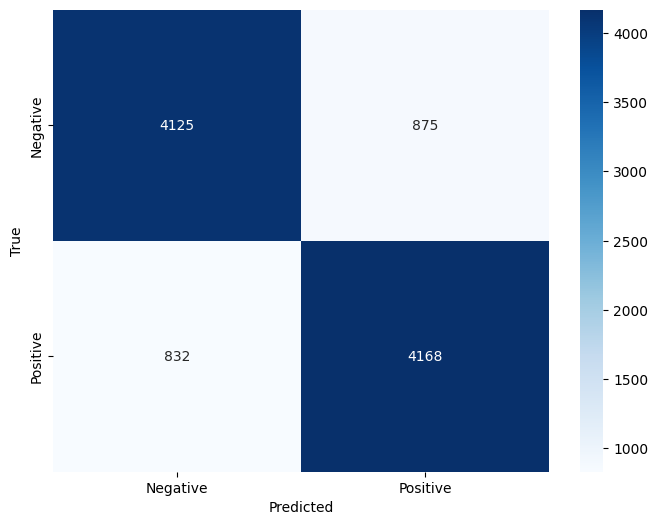

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

f1 = f1_score(y_true, y_pred)
print(f"F1 Score: {f1}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()